In [1]:
!pip install openai sentence-transformers

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

class InterModelEvaluator:
    def __init__(self, api_key):
        print("Initializing Inter-Model Evaluator via Euron Gateway...")
        self.client = OpenAI(
            base_url="https://api.euron.one/api/v1/euri",
            api_key=api_key
        )
        self.embedder = SentenceTransformer('all-MiniLM-L6-v2')
        self.data_corpus = []
        print("Initialization complete.")

    def generate_api_responses(self, prompts, models, iterations=10, temperature=1.0):
        self.data_corpus = []
        for model_name in models:
            print(f"--- Generating data from {model_name} ---")
            for prompt in prompts:
                for i in range(iterations):
                    try:
                        response = self.client.chat.completions.create(
                            model=model_name,
                            messages=[{"role": "user", "content": prompt}],
                            temperature=temperature,
                            max_tokens=150
                        )
                        generated_text = response.choices[0].message.content.strip()
                        self.data_corpus.append({
                            'Model': model_name,
                            'Prompt': prompt,
                            'Response': generated_text
                        })
                        print(f"[{model_name}] Response {i+1}/{iterations} collected.")
                    except Exception as e:
                        print(f"Error querying {model_name}: {e}")
        return pd.DataFrame(self.data_corpus)

    def compute_vector_space(self, df):
        print("\nVectorizing AI responses into 384-dimensional space...")
        text_list = df['Response'].tolist()
        embeddings = self.embedder.encode(text_list)
        return embeddings

    def visualize_hivemind_clusters(self, df, embeddings):
        print("Running t-SNE Dimensionality Reduction...")
        perplexity_value = min(5, len(df) - 1)
        tsne = TSNE(n_components=2, perplexity=perplexity_value, random_state=42)
        tsne_results = tsne.fit_transform(embeddings)

        df['tsne_x'] = tsne_results[:, 0]
        df['tsne_y'] = tsne_results[:, 1]

        plt.figure(figsize=(10, 8))
        sns.scatterplot(
            x='tsne_x', y='tsne_y',
            hue='Model',
            style='Prompt',
            palette='Set1',
            data=df,
            s=100,
            alpha=0.8
        )
        plt.title('Inter-Model Hivemind: Semantic Overlap Across Different Architectures', fontsize=14)
        plt.xlabel('t-SNE Dimension 1')
        plt.ylabel('t-SNE Dimension 2')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

In [6]:
# PASTE YOUR API KEY HERE
API_KEY = "euri-1405844edc9a6597d9ff53e2baeddfbbe29e29d665e0d8442529c96c8bbef47d"

# Initialize the evaluator
evaluator = InterModelEvaluator(api_key=API_KEY)

# Define the prompts we are using to test for the "Hivemind"
prompts_to_test = [
    "Write a highly creative, unconventional metaphor about the nature of time.",
    "Propose a completely out-of-the-box solution to urban traffic."
]

# Use the exact API strings we verified from your Euron dashboard
models_to_test = [
    "gpt-4.1-mini",
    "llama-3.3-70b-versatile",
    "gemini-2.5-flash"
]

# This cell will run the experiment and save all data into a table (df_results)
df_results = evaluator.generate_api_responses(
    prompts=prompts_to_test,
    models=models_to_test,
    iterations=10
)



# This forces Colab to show every single row and doesn't cut off the text
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# Display the full table
df_results

Initializing Inter-Model Evaluator via Euron Gateway...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Initialization complete.
--- Generating data from gpt-4.1-mini ---
[gpt-4.1-mini] Response 1/10 collected.
[gpt-4.1-mini] Response 2/10 collected.
[gpt-4.1-mini] Response 3/10 collected.
[gpt-4.1-mini] Response 4/10 collected.
[gpt-4.1-mini] Response 5/10 collected.
[gpt-4.1-mini] Response 6/10 collected.
[gpt-4.1-mini] Response 7/10 collected.
[gpt-4.1-mini] Response 8/10 collected.
[gpt-4.1-mini] Response 9/10 collected.
[gpt-4.1-mini] Response 10/10 collected.
[gpt-4.1-mini] Response 1/10 collected.
[gpt-4.1-mini] Response 2/10 collected.
[gpt-4.1-mini] Response 3/10 collected.
[gpt-4.1-mini] Response 4/10 collected.
[gpt-4.1-mini] Response 5/10 collected.
[gpt-4.1-mini] Response 6/10 collected.
[gpt-4.1-mini] Response 7/10 collected.
[gpt-4.1-mini] Response 8/10 collected.
[gpt-4.1-mini] Response 9/10 collected.
[gpt-4.1-mini] Response 10/10 collected.
--- Generating data from llama-3.3-70b-versatile ---
[llama-3.3-70b-versatile] Response 1/10 collected.
[llama-3.3-70b-versatile] R

,Model,Prompt,Response
0,gpt-4.1-mini,"Write a highly creative, unconventional metaphor about the nature of time.","Time is a restless spider weaving a web made not of silk, but of whispers and lost footsteps—each thread shimmering with the echoes of moments not yet lived, catching the sunlight of memory before it slips into the shadows of forever."
1,gpt-4.1-mini,"Write a highly creative, unconventional metaphor about the nature of time.","Time is a restless librarian in a labyrinthine archive, eternally shelving moments on invisible, shifting shelves that rearrange themselves with every blink—so that what was once a whisper from the past is suddenly a secret hidden behind doors that don’t exist yet."
2,gpt-4.1-mini,"Write a highly creative, unconventional metaphor about the nature of time.","Time is a restless library cat that naps on the spine of every forgotten book, purring threads of moments that weave and unravel simultaneously beneath shadows no one remembers casting."
3,gpt-4.1-mini,"Write a highly creative, unconventional metaphor about the nature of time.","Time is a restless origami crane, folding and unfolding itself in infinite complexity—each crease a memory, each flap a possibility—so delicate that the slightest breath of a thought can reshape its shape forever, yet sturdy enough to carry the weight of eternity on wings made of moments."
4,gpt-4.1-mini,"Write a highly creative, unconventional metaphor about the nature of time.","Time is a kaleidoscope spun by a sleepy octopus in a library where books write themselves backwards—each twist rearranges moments into fractal mosaics of past and future, impossible to read linearly yet endlessly mesmerizing in their ever-shifting patterns."
5,gpt-4.1-mini,"Write a highly creative, unconventional metaphor about the nature of time.","Time is a restless jazz musician trapped inside a kaleidoscope, endlessly riffing through shifting colors and fractured moments—each beat a twisted reflection, never settling, forever scattering the now into shimmering shards that only the soul can hear rearranging themselves into new melodies."
6,gpt-4.1-mini,"Write a highly creative, unconventional metaphor about the nature of time.","Time is a restless librarian who never stops rearranging the infinite shelves of moments, slipping forgotten memories into whispered footnotes while scribbling tomorrow’s secrets in invisible ink."
7,gpt-4.1-mini,"Write a highly creative, unconventional metaphor about the nature of time.","Time is a kaleidoscopic octopus knitting endless scarves from the forgotten whispers of stardust—each twist of its tentacles unfurling new patterns that shimmer between memory and possibility, never the same two moments woven twice."
8,gpt-4.1-mini,"Write a highly creative, unconventional metaphor about the nature of time.","Time is a restless origami crane folded from the whisper of a dream—a delicate shape that unfolds only to reveal new creases, each crease a secret corridor spiraling into invisible galaxies where moments shimmer and dissolve like stardust ink on the vellum of forever."
9,gpt-4.1-mini,"Write a highly creative, unconventional metaphor about the nature of time.","Time is a seamstress weaving a tapestry from invisible threads—each moment a stitch that both unravels the past and entwines the future, crafting patterns we only glimpse by accident, as if the fabric of existence is stitched backward through a mirror’s whispered secrets."



Vectorizing AI responses into 384-dimensional space...
Running t-SNE Dimensionality Reduction...


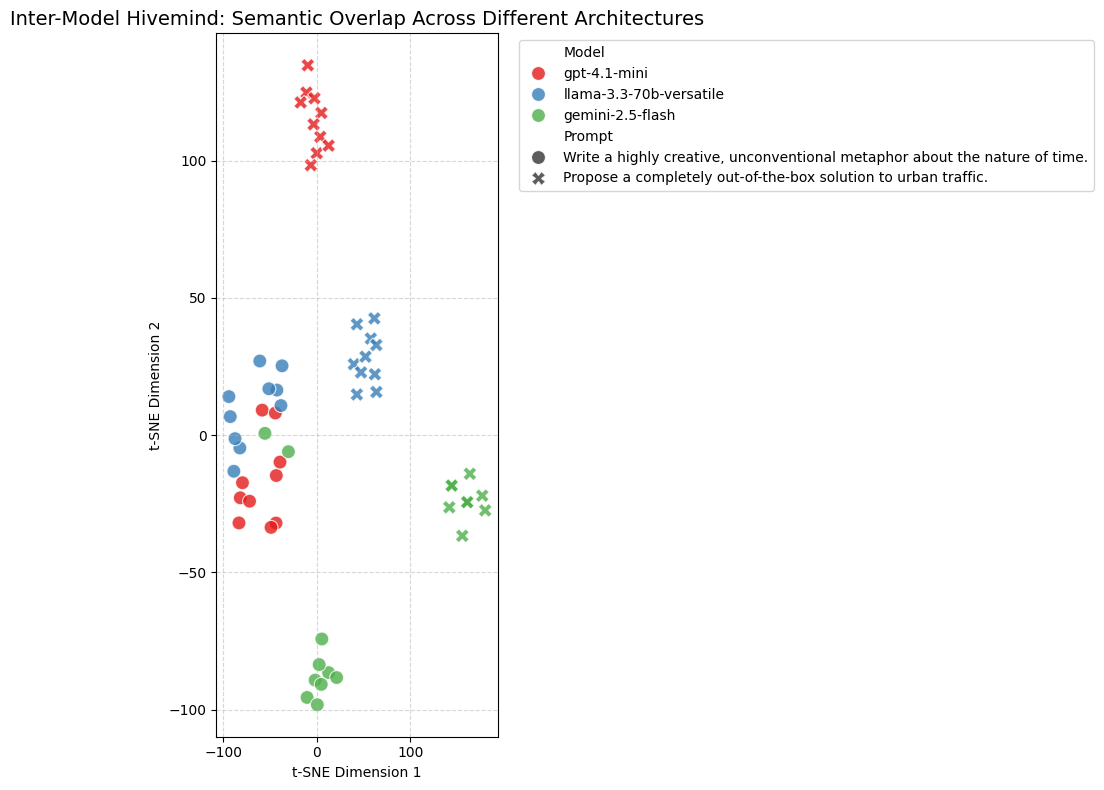

In [7]:
# Step 1: Convert the text into 384-dimensional vectors
embeddings = evaluator.compute_vector_space(df_results)

# Step 2: Run the t-SNE algorithm and generate the scatterplot
# If the dots overlap, you've officially proven the Inter-Model Hivemind!
evaluator.visualize_hivemind_clusters(df_results, embeddings)

Generating Numerical Proof of Inter-Model Hivemind...


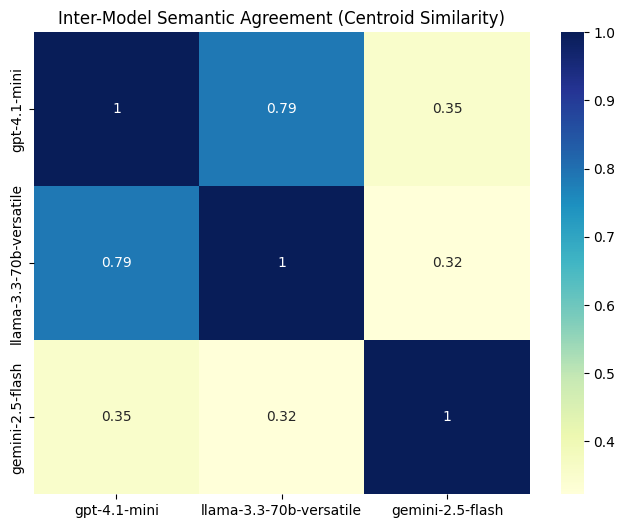


--- FINAL NUMERICAL PROOF ---
Agreement between gpt-4.1-mini and llama-3.3-70b-versatile: 78.63%
Agreement between gpt-4.1-mini and gemini-2.5-flash: 35.40%
Agreement between llama-3.3-70b-versatile and gemini-2.5-flash: 32.23%


In [8]:
from sklearn.metrics.pairwise import cosine_similarity

def generate_inter_model_analysis(df, embeddings):
    print("Generating Numerical Proof of Inter-Model Hivemind...")

    # 1. Calculate the mean vector for each model to find its 'Centroid'
    model_names = df['Model'].unique()
    centroids = {}
    for model in model_names:
        idx = df[df['Model'] == model].index
        centroids[model] = np.mean(embeddings[idx], axis=0)

    # 2. Compute Similarity between the models themselves
    centroid_matrix = []
    for m1 in model_names:
        row = []
        for m2 in model_names:
            sim = cosine_similarity(centroids[m1].reshape(1, -1), centroids[m2].reshape(1, -1))[0][0]
            row.append(sim)
        centroid_matrix.append(row)

    # 3. Plot the Inter-Model Agreement Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(centroid_matrix, annot=True, xticklabels=model_names, yticklabels=model_names, cmap='YlGnBu')
    plt.title('Inter-Model Semantic Agreement (Centroid Similarity)')
    plt.show()

    # 4. Print the "Smoking Gun" Statistics
    print("\n--- FINAL NUMERICAL PROOF ---")
    for i, m1 in enumerate(model_names):
        for j, m2 in enumerate(model_names):
            if i < j:
                agreement = centroid_matrix[i][j] * 100
                print(f"Agreement between {m1} and {m2}: {agreement:.2f}%")

# Run the analysis
generate_inter_model_analysis(df_results, embeddings)